In [3]:
## test models R squared performance ##
import sys
import pandas as pd

sys.path.append('..')

from models import RSM, RandomForestModel, XGBModel, GPModel, BayesianNetworkModel 


SEED = 1312
sizes = [30, 60, 125, 250, 500]
problems = [1,2,3]

for problem in problems:

    if problem==1:
        targets = ['intrusion', 'specific_energy_absorbed']
    elif problem==2:
        targets = ['intrusion', 'mass']
    elif problem==3:
        targets = ['load_uniformity']

    df = pd.DataFrame()
    df["size"] = ["30D", "60D", "125D", "250D", "500D"]
    for size in sizes:
        models = {
            "rsm" : {f'rsm_{target}' : RSM.load(f'RSM_{target}_p{problem}_{size}D.pkl', target=target, problem=problem, dset_size=size, seed=SEED) for target in targets},
            "rf" : { f'rf_{target}': RandomForestModel.load(f'RF_{target}_p{problem}_{size}D.pkl', target=target, problem=problem, dset_size=size, seed=SEED) for target in targets },
            "xgb" : {f'xgb_{target}' : XGBModel.load(f'XGB_{target}_p{problem}_{size}D.ubj', target=target, problem=problem, dset_size=size, seed=SEED) for target in targets},
            "gp" : {f'gp_{target}' : GPModel.load(f'GP_{target}_p{problem}_{size}D.pt')for target in targets},#, target=target, problem=problem, dset_size=size, seed=SEED) for target in targets},
            "bn" : {f'bayesian' : BayesianNetworkModel.load(f"BN_p{problem}_{size}D.pkl", problem=problem, dset_size=size, seed=SEED)}
        }


        model_scores = {}
        for model_class, model_dict in models.items():
            for model_name, _ in model_dict.items():
                model_scores[model_name] = None     
        



        #TODO: evaluate models
        r2_values = {}
        for model_class, model_dict in models.items():
            for model_name, model in model_dict.items():
                if model_class == 'bn':
                    preds = model.pred()
                    metrics = model.metrics(preds)
                    for target in model.targets:
                        # r2 = metrics[target]['r-squared']
                        #TODO: save value
                        r2_values[f'bayesian_{target}'] = metrics[target]['r-squared']
                else:
                    preds = model.pred()
                    metrics = model.metrics(preds)
                    # r2 = metrics['r-squared']
                    r2_values[model_name] = metrics['r-squared']
            
        for model_name, r2_value in r2_values.items():
            df.loc[df['size'] == f"{size}D", model_name] = r2_value
                

        # for model_name, r2_value in r2_values.items():
        #     df.loc[df['size']==f"{size}D", 'model_name'] = r2_value

    # print(df)
    df.to_csv(f'r2_scores/r2_problem{problem}.csv', index=False)
    

In [ ]:
# covnergence data tools

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fancy_names_models = {
    'rsm': 'Response Surface Methodology',
    'rf': 'Random Forest',
    'xgb': 'XGBoost',
    'gp': 'Gaussian Process',
    'bn': 'Bayesian Network'
}

fancy_names_optimizers = {
    'cmaes': 'CMA-ES',
    'turbo1': 'TuRBO-1',
    'botorch': 'BoTorch',
    'baxus': 'BAxUS',
    'de': 'DE',
    'one_plus_one': '1+1 ES'
}

def dat_to_df(dat):
    return pd.read_csv(dat, sep='\s+')

def read_convergence_data(filename):
    data = {
        'evaluations': [],
        'best': []
    }
    df = dat_to_df(filename)
        # for line_nr, line in enumerate(file):
        #     if line_nr == 0:
        #         continue
        #     line = line.strip()
        #     cols = line.split()
        
        #     data['evaluations'].append(float(cols[0]))
        #     data["best"].append(float(cols[2])) #TODO: check that this is current minimum
    
    df['best'] = df['raw_y'].cummin() 


    data['evaluations'] = df['evaluations'].to_list()
    data['best'] = df['best'].to_list()
    
    return data

def plt_convergence_curve(data, model_class, problem, optimizer):
    # data will have a dict for each run that contains problem, size, class, optimizer, dim, best and path
    #TODO: define colors for each optimizer

    # per_optimizer_data = [optimizer for optimizer in data if optimizer["problem"]==problem and optimizer["size"]==size and optimizer["model_class"]==model_class] 

    fig, ax = plt.subplots(figsize=(8,5))

    # for d in data:
    for size, size_data in data.items():#.items():
        ax.plot(
            size_data['evaluations'],
            size_data['best'],
            label=size #TODO: color
        )

    ax.set_xlabel("Function evaluations")
    ax.set_ylabel("Current best f(x)")
    ax.set_title(f"{fancy_names_models[model_class]} optimized with {fancy_names_optimizers[optimizer]} (Problem {problem})")
    ax.legend(title='Training set size (\u00d7n_dimensions)')
    # ax.grid(True, ls)
    plt.tight_layout()
    return fig

def aocc(best, lb, ub):

    y = np.asarray(best, dtype=float)
    y_normalized = (np.minimum(np.maximum(y, lb), ub) - lb)/(ub-lb)
    aocc = 1-y_normalized
    return float(np.mean(aocc))

def get_ranking(problem, model):
    aocc_table = pd.read_csv(f'aocc_tables/p{problem}/aocc_{model}.csv')
    sorted_all_sizes = {
        '30D': [],
        '60D': [],
        '125D': [],
        '250D': [],
        '500D': []

    }
    
    for size in aocc_table.iloc[:,:]:
        if size not in ['30', '60', '125', '250', '500']:
            optimizers = aocc_table[size]
            continue
        size_aoccs = aocc_table[size]
        # optimizers = size_aoccs.index.values
        size_list = []
        # for size_aocc in size_aoccs:
        #     for optimizer in optimizers:
        for size_aocc, optimizer in zip(size_aoccs, optimizers):
                # aocc = float(aocc_table.loc[optimizer, size])
            size_list.append((size_aocc, optimizer))
        # optimizers = size.index.values()
        # size_list = []
        # for optimizer in optimizers:
        #     aocc = size[optimizer]
        #     size_list.append((aocc, optimizer))
        
        sorted_algos = sorted(size_list, reverse=True)
        for _, algo in sorted_algos:
            sorted_all_sizes[f'{size}D'].append(fancy_names_optimizers[algo])
        # sorted_all_sizes[f'{size}D'] = 
        # print(sorted_algos)

        
    ranking_df = pd.DataFrame(sorted_all_sizes)
    

    return ranking_df

    
    


<>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_2748/3735652728.py:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  return pd.read_csv(dat, sep='\s+')


/tmp/ipykernel_7387/1816038028.py:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  return pd.read_csv(dat, sep='\s+')


TypeError: list indices must be integers or slices, not str

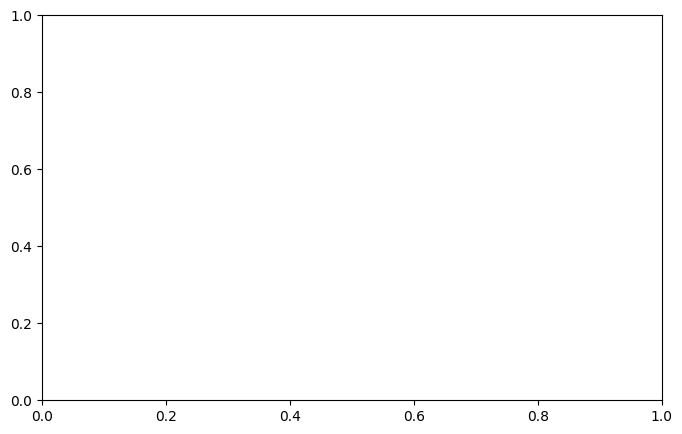

In [ ]:
# plot 
from glob import glob
problems = [1,2,3]
sizes = [30,60,125,250,500]
model_classes = ['rsm', 'rf', 'xgb', 'gp']#, 'bn']
optimizers = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']


data_directory = 'bich'
data = []



for problem in problems:
    dim = 5 if problem ==1 or problem ==2 else 15
    for optimizer in optimizers:
        for model in model_classes:
        # for size in sizes:
            # print(dim, problem, model, optimizers)
            # print(glob(f'logger_data/p{problem}/{model}/{size}D/{optimizer}/data_f*_p{problem}_{optimizer}_{size}D/IOHprofiler_f*_DIM{dim}.dat'))
            paths = [glob(f'../alice/logger_data/p{problem}/{model}/{size}D/{optimizer}8/data_f*_p{problem}_{model}_{size}D/IOHprofiler_f*_DIM{dim}.dat')[0] for size in sizes]
            # for optimizer in optimizers:
            #     pattern = f'logger_data/p{problem}/{model}/{size}D/{optimizer}/data_f*_p{problem}_{optimizer}_{size}D/IOHprofiler_f*_DIM{dim}.dat'
            #     matches = glob(pattern)
            #     if not matches:
            #         print(f"MISSING: {pattern}")
                
            data = [read_convergence_data(path) for path in paths]
            for datum in data:
                fig = plt_convergence_curve(datum, model, problem, optimizer)
                plt.close(fig)
            # input('hi')
            # fig.savefig(f'plots/p{problem}/{model}/ranking_{size}D.png')
            # plt.close(fig)

In [2]:
# compute AOCC and save rankings
from glob import glob 

problems = [1,2,3]
sizes = [30,60,125,250,500]
model_classes = ['rsm', 'rf', 'xgb', 'gp']#, 'bn']
optimizers = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']
optimizer_scores = {
    'p1': None,
    'p2': None,
    'p3': None
}
ub = 1e+4
lb = 1e-8

for problem in problems:
    if problem == 1 or problem == 2: 
        dim=5 
    else: 
        dim = 15
    optimizer_scores[f'p{problem}'] = {f'{model}': None for model in model_classes}
    for model in model_classes:
        optimizer_scores[f'p{problem}'][f'{model}'] = {f'{size}D': {} for size in sizes}
        for size in sizes:
            data = {}
            # paths = [f'logger_data/p{problem}/{model}/{size}D/{optimizer}/SOMETHING/IOHprofiler_fSOMETHING_DIM{dim}.dat' for optimizer in optimizers]
            # data = [read_convergence_data(path) for path in paths]
            for optimizer in optimizers:
                path = glob(f'logger_data/p{problem}/{model}/{size}D/{optimizer}/data_f*_p{problem}_{model}_{size}D/IOHprofiler_f*_DIM{dim}.dat')[0]

                data = read_convergence_data(path)
                optimizer_aocc = aocc(data['best'], lb, ub) 
                # optimizer_scores[f'p{problem}'][f'{model}'][f'{size}D'].update({optimizer: optimizer_aocc})
                optimizer_scores[f'p{problem}'][f'{model}'][f'{size}D'][optimizer] = optimizer_aocc
            
for problem in problems:
    all_rankings = []
    for model in model_classes:
        ranking_per_size_df = pd.DataFrame(index=optimizers)
        # ranking_per_size_df['optimizers'] = optimizers
        for size in sizes:
            for optimizer in optimizers:
                ranking_per_size_df.loc[optimizer,size] = optimizer_scores[f'p{problem}'][f'{model}'][f'{size}D'][optimizer]
        
        all_rankings.append(ranking_per_size_df)
        ranking_per_size_df.to_csv(f'aocc_tables/p{problem}/aocc_{model}.csv')



In [ ]:
# ranking plots

In [57]:
# make ranking csvs
problems = [1,2,3]
model_classes = ['rsm', 'rf', 'xgb', 'gp']#, 'bn']
for problem in problems:
    for model in model_classes:
        rankings_df = get_ranking(problem, model)
        rankings_df.to_csv(f"rankings_tables/p{problem}/rankings_{model}.csv")

In [ ]:
# kendall's tau

from scipy import stats

ranking_pairs = {
    mechbench_p1 : {},
    mechbench_p2 : {},
    mechbench_p3 : {}
}

for problem in problems:
    for model in model_classes:
        for size in sizes:
            ranking = get_model_ranking(problem, model, size)

similarity = stats.kendalltau(ranking1, ranking2)

# Do analysis steps:

In [1]:
from analysis_utils import *

/home/odysseas/dsai/thesis/sMECHBench/analysis/analysis_utils.py:92: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  return pd.read_csv(dat, sep='\s+')
/home/odysseas/miniconda3/envs/conda_mechbench/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [2]:
# r2
all_models_r2()

,size,rsm_load_uniformity,rf_load_uniformity,xgb_load_uniformity,gp_load_uniformity,bayesian_load_uniformity
0,30D,0.177455,0.625151,0.750633,0.111540,-0.038992
1,60D,0.221568,0.662769,0.661652,0.179055,0.005527
2,125D,0.287605,0.681532,0.697877,0.274885,0.017033
3,250D,0.402539,0.760587,0.767286,0.362877,0.003952
4,500D,0.437716,0.780293,0.791912,0.396383,0.013885


In [ ]:
# make convergence data dicts
from glob import glob

algos = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']
model_classes = ['rsm', 'rf', 'xgb', 'gp', 'bn']
convergence_p1 = {}
convergence_p2 = {}
convergence_p3 = {}

problem_dicts = [convergence_p1, convergence_p2, convergence_p3]

#TODO: seeds missing
for i, problem_dict in enumerate(problem_dicts):
    problem = i+1
    # mechbench conv data
    mechbench_dir = f'logger_data/mechbench/p{problem}'
# {optimizer}/data_f*_p{problem}_{model}_{size}D/IOHprofiler_f*_DIM{dim}.dat')[0]

    problem_dict['mechbench'] = {}

    for optimizer in algos:
        optimizer_path = glob(f'{mechbench_dir}/{optimizer}/data_f*_mechbench_p{problem}/IOHprofiler_f*_DIM{dim}.dat')[0]
        convergence_data = read_convergence_data(optimizer_path)
        problem_dict['mechbench'][optimizer] = convergence_data

    for model in model_classes:
        model_dir = f'logger_data/p{problem}'
        problem_dict[model] = {}

        for optimizer in algos:
            optimizer_path = glob(f'{model_dir}/{optimizer}/data_f*_p{problem}_{model}_{size}D/IOHprofiler_f*_DIM{dim}.dat')[0]
            convergence_data = read_convergence_data(optimizer_path)
            problem_dict[model][optimizer] = convergence_data
    




In [ ]:
# plot convergence
problems = [1, 2, 3]
models = ['rsm', 'rf', 'xgb', 'gp', 'bn']
sizes = [30, 60, 125, 250, 500]
optimizers = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']

for problem in problems:
    problem_dict = problem_dicts[problem-1]
    mbench_plot = plt_convergence_curve(problem_dict['mechbench'], 'mechbench', problem, None)
    mbench_plot.savefig(f'convergence_curve_plots/p{problem}/mechbench/mechbench_p{problem}_convergence_curve.png')
    for model in models:
        for size in sizes:
            model_plot = plt_convergence_curve(problem_dict[model], model, problem, size)
            model_plot.savefig(f'convergence_curve_plots/p{problem}/{model}/{model}_p{problem}_{size}D_convergence_curve.png')


In [ ]:
# plot rankings
problems = [1,2,3]
models = ['rsm', 'rf', 'xgb', 'gp', 'bn']
sizes = [30, 60, 125, 250, 500]
optimizers = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']

for problem in problems:
    problem_dict = problem_dicts[problem-1]
    
    mechbench_plot = plt_rank(problem_dict['mechbench'], problem, 'mechbench', None)
    mechbench_plot.savefig(f'ranking_plots/p{problem}/mechbench/mechbench_p{problem}_ranking.png')
    for model in models:
        for size in sizes:
            model_plot = plt_rank(problem_dict[model], problem, model, size)
            model_plot.savefig(f'ranking_plots/p{problem}/{model}/{model}_p{problem}_{size}D_ranking.png')

In [ ]:
# kendall's tau matrix 
problems = [1,2,3]
models = ['rsm', 'rf', 'xgb', 'gp', 'bn']
sizes = [30, 60, 125, 250, 500]
optimizers = ['cmaes', 'turbo1', 'botorch', 'baxus', 'de', 'one_plus_one']
slices = None #TODO: figure out slices

mechbench_rankings = {}
for problem in problems:
    mechbench_rankings[problem] = rank(problem_dicts[problem-1]['mechbench'])
    model_rankings = {}
    for model in models:
        model_rankings[model] = {}
        for size in sizes:
            model_rankings[model][size] = rank(problem_dict[problem-1][model][size])


for problem in problems:
    tau = kendalls_tau(problem, mechbench_rankings, model_rankings, models, sizes, slices)



NameError: name 'problem_dicts' is not defined